# 5G Network Slicing: Comprehensive KG-LoRA Recommendation System
This notebook demonstrates a complete, optimized pipeline to fine-tune **Llama 3.2-1B-Instruct** using 10 steps. Includes evaluation and full metrics.

In [1]:
### STEP 1: ENVIRONMENT SETUP & DEPENDENCIES
# Detailed Technical Steps:
# 1. Install `pandas`, `networkx`, and `matplotlib` for tabular data manipulation and Knowledge Graph (KG) creation/visualization.
# 2. Install `torch` as the core deep learning backend.
# 3. Install `transformers` to load the Llama 3 model and tokenizer.
# 4. Install `datasets` to manage the training data efficiently.
# 5. Install `peft` (Parameter-Efficient Fine-Tuning) to apply LoRA, which freezes the base model and only trains low-rank adapter matrices.
# 6. Install `trl` (Transformer Reinforcement Learning) which provides the `SFTTrainer` for supervised fine-tuning.
# 7. Install `bitsandbytes` and `accelerate` for handling 4-bit model quantization and efficient memory management on GPUs.
!python3 -m pip install -q pandas networkx matplotlib torch transformers datasets peft trl bitsandbytes accelerate scikit-learn


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
### STEP 2: LIBRARY IMPORTS & GLOBAL CONFIGURATION
# Detailed Technical Steps:
# 1. Import necessary libraries for data processing, graph theory, and PyTorch/HuggingFace ML tasks.
# 2. Safely load the Hugging Face access token (`HF_TOKEN`) from the environment variables to authenticate with the Hugging Face Hub (required for Llama-3).
# 3. Define the base model ID (`meta-llama/Llama-3.2-1B-Instruct`) which will be downloaded and fine-tuned.
# 4. Set the `OUTPUT_DIR` where the trained LoRA adapter weights and updated tokenizer will be saved.
import os
import gc
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTConfig, SFTTrainer

os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN", "")
if not os.environ["HF_TOKEN"]:
    print("Warning: HF_TOKEN environment variable not set.")
MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
OUTPUT_DIR = "./comprehensive-5g-adapter"

/Users/kelly/Library/Python/3.10/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Processing & SVO Creation

In [3]:
### STEP 3: KNOWLEDGE GRAPH (KG) CONSTRUCTION FROM TABULAR DATA
# Detailed Technical Steps:
# 1. `parse_all_params`: A helper function to split the raw 'Parameters' string (e.g., 'Throughput=10|Latency=5') into a Python dictionary.
# 2. Load the 5G network slicing dataset using `pandas`.
# 3. Iterate through each row of the dataset to extract the standard tag (e.g., 'TS 23.501'). This acts as the 'Subject' node in our KG.
# 4. For each row, create a direct 'defines_recommendation' edge (Predicate) linking the standard tag (Subject) to the target slice plan (Object).
# 5. For every other network parameter (throughput, latency, etc.), dynamically generate an 'observed_<parameter>' edge linking the standard to that specific metric value.
# 6. Convert the list of dictionaries into a Pandas DataFrame representing the Subject-Predicate-Object triples, dropping duplicates to form a clean graph edge list.
def parse_all_params(params_str):
    parts = params_str.split("|")
    return {p.split("=")[0].strip(): p.split("=")[1].strip() for p in parts if "=" in p}

df = pd.read_csv("../network_slicing_300.csv")
kg_triples = []

for idx, row in df.iterrows():
    params = parse_all_params(row["Parameters"])
    tag = params.get("StdTag", "Unknown")
    kg_triples.append({"subject": tag, "predicate": "defines_recommendation", "object": row["Recommendation"]})
    for key, value in params.items():
        if key != "StdTag":
            kg_triples.append({"subject": tag, "predicate": f"observed_{key.lower()}", "object": value})

kg_df = pd.DataFrame(kg_triples).drop_duplicates()
display(kg_df.head(15))

,subject,predicate,object
0,TS 23.501,defines_recommendation,"TS 23.501 eMBB QoS tune, URLLC latency hold, m..."
1,TS 23.501,observed_throughput,715Mbps
2,TS 23.501,observed_latency,11ms
3,TS 23.501,observed_reliability,99.967%
4,TS 23.501,observed_density,2533devices/km2
5,TS 23.501,observed_mobility,58km/h
6,TS 23.501,observed_error,Scale lag
8,TS 23.501,observed_throughput,809Mbps
9,TS 23.501,observed_latency,6ms
10,TS 23.501,observed_reliability,99.972%


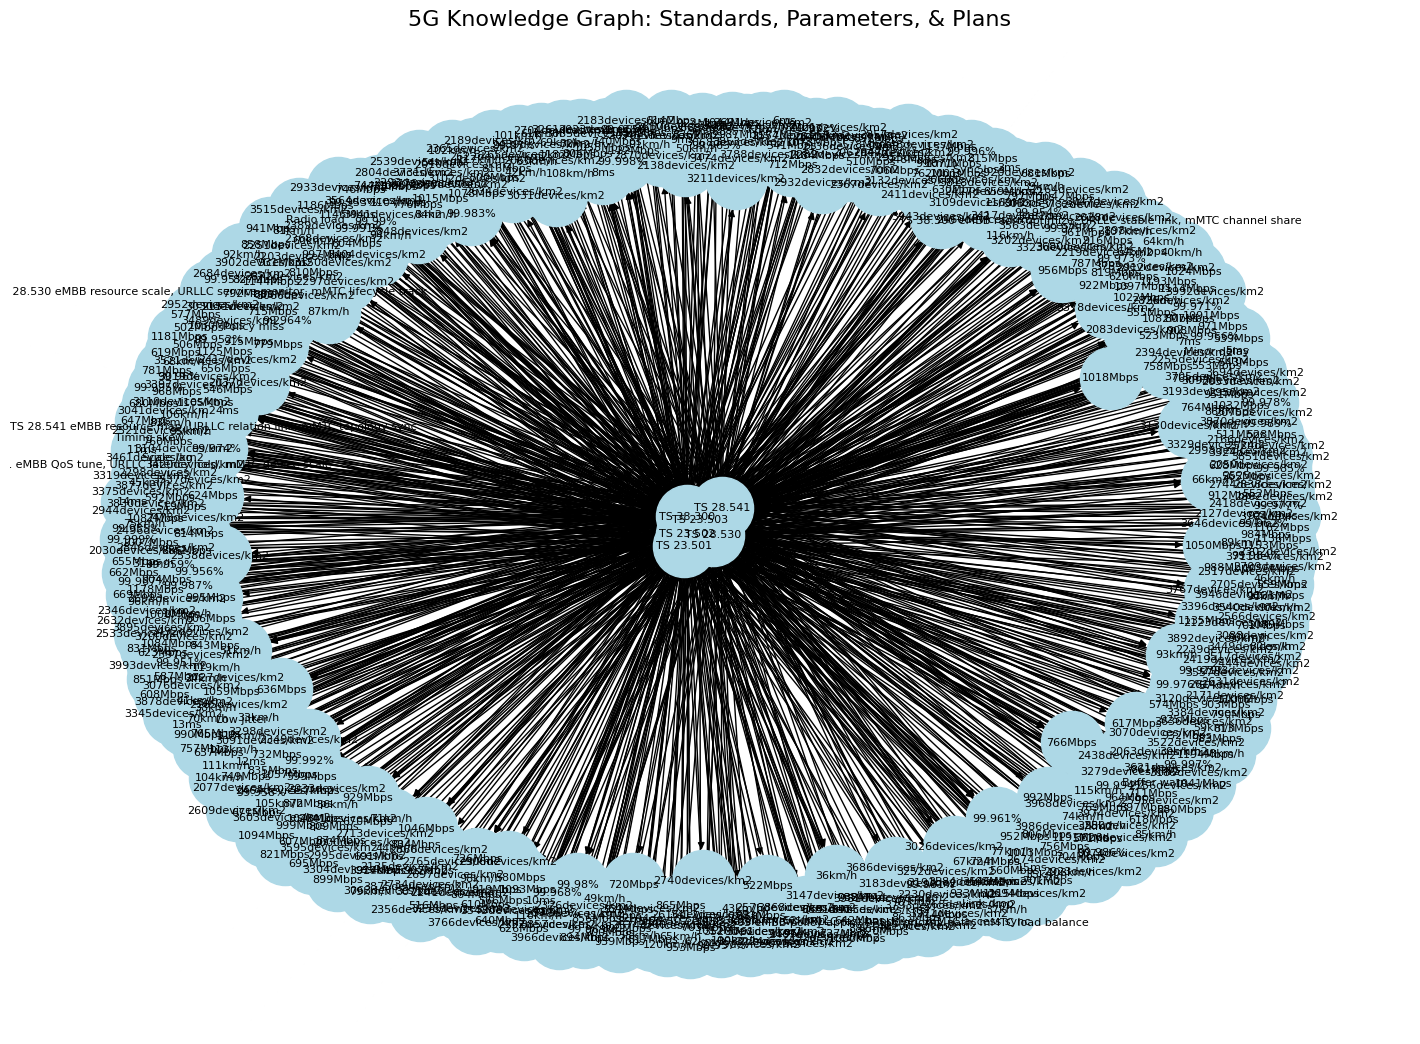

In [4]:
### STEP 4: KNOWLEDGE GRAPH VISUALIZATION
# Detailed Technical Steps:
# 1. Convert the Pandas edge list into a NetworkX Directed Graph (`nx.DiGraph`). Nodes are automatically inferred from the 'subject' and 'object' columns.
# 2. Initialize a matplotlib figure with a large display size to accommodate the nodes.
# 3. Use `nx.spring_layout` to position the nodes. The spring layout uses a force-directed algorithm (treating edges as springs) to separate disconnected components.
# 4. Draw the graph, applying specific styling (node size, color, font size, arrows for direction) to illustrate the ontology of the 5G network parameters.
G = nx.from_pandas_edgelist(kg_df, source="subject", target="object", edge_attr="predicate", create_using=nx.DiGraph())
plt.figure(figsize=(14, 10))
nx.draw(G, nx.spring_layout(G, k=0.7), with_labels=True, node_color="#ADD8E6", node_size=2000, font_size=8, arrows=True)
plt.title("5G Knowledge Graph: Standards, Parameters, & Plans", fontsize=16)
plt.show()

In [5]:
### STEP 5: INSTRUCTION DATASET PREPARATION & PROMPT ENGINEERING
# Detailed Technical Steps:
# 1. `build_prompt`: Formats the tabular data into conversational prompts exactly matching the Llama-3 special token syntax.
# 2. `<|begin_of_text|>`: Signals the start of the sequence.
# 3. System prompt (`<|start_header_id|>system<|end_header_id|>`): Injects the AI persona and instructions.
# 4. User prompt (`<|start_header_id|>user...`): Provides the raw input parameters to the model.
# 5. Assistant response (`<|start_header_id|>assistant...`): Provides the expected ideal output (Standard + Recommendation) terminated by `<|eot_id|>` (End of Turn).
# 6. The Pandas DataFrame is converted to a HuggingFace `Dataset` object.
# 7. The prompt formatting function is applied across the entire dataset using `.map()`.
# 8. The dataset is split 90/10 into training (`train_ds`) and evaluation (`eval_ds`) subsets.
def build_prompt(row):
    params = row['Parameters']
    std_tag = "Unknown"
    for p in params.split("|"):
        if "StdTag=" in p:
            std_tag = p.split("=")[1].strip()
    return (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
        f"You are an expert 5G network AI. Analyze the external parameters and error messages, associate them with the correct standard from the Knowledge Graph, and recommend the corresponding network slicing plan.<|eot_id|>\n"
        f"<|start_header_id|>user<|end_header_id|>\n"
        f"External Parameters & Error: {params}<|eot_id|>\n"
        f"<|start_header_id|>assistant<|end_header_id|>\n"
        f"Associated Standard: {std_tag}\n"
        f"Recommended Plan: {row['Recommendation']}<|eot_id|>"
    )

dataset = Dataset.from_pandas(df)
dataset = dataset.map(lambda x: {"text": build_prompt(x)})

dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
train_ds = dataset_split["train"]
eval_ds = dataset_split["test"]

Map: 100%|██████████| 300/300 [00:00<00:00, 11850.21 examples/s]


In [6]:
### STEP 6: MODEL INITIALIZATION & LORA SUPERVISED FINE-TUNING
# Detailed Technical Steps:
# 1. Tokenizer Setup: Load the Llama-3 tokenizer and configure the padding token to be the EOS (End Of Sequence) token.
# 2. Quantization Logic: Check if the system is running on Apple Silicon (MPS). `bitsandbytes` 4-bit (NF4) quantization is highly unstable on MPS, so we load the model in standard FP16 precision on Mac, but use 4-bit on CUDA to save memory.
# 3. LoRA Configuration (`LoraConfig`): 
#    - `r=32`: The rank of the low-rank matrices. Higher means more capacity but more VRAM.
#    - `lora_alpha=64`: The scaling factor for the LoRA weights.
#    - `target_modules`: We target Q, K, V, O attention projections and MLP layers (gate, up, down) for maximum adaptability.
#    - `lora_dropout=0.05`: Adds regularization to prevent overfitting.
# 4. Adapter Integration: `get_peft_model` wraps the frozen base model with the trainable LoRA layers, drastically reducing the total trainable parameters.
# 5. Training Arguments (`SFTConfig`):
#    - `gradient_accumulation_steps=4`: Accumulates gradients over 4 sub-steps to simulate a larger batch size (4 * 2 = 8 total batch size) under memory constraints.
#    - `learning_rate=2e-4`: Standard LR for LoRA fine-tuning.
#    - `dataloader_num_workers=0`: Prevents multiprocessing deadlocks on MPS.
# 6. Execution: Initialize `SFTTrainer`, execute the training loop, and save the adapter weights locally.
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

use_4bit = not torch.backends.mps.is_available()
if use_4bit:
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=quant_config, device_map="auto")
else:
    print("Quantization disabled for MPS stability. Loading in FP16.")
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")

lora_config = LoraConfig(
    r=32, 
    lora_alpha=64, 
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

training_args = SFTConfig(
    output_dir=OUTPUT_DIR, 
    max_steps=10, 
    num_train_epochs=1,
    per_device_train_batch_size=2, 
    gradient_accumulation_steps=4,
    eval_strategy="steps", 
    eval_steps=5, 
    learning_rate=2e-4, 
    optim="adamw_torch", 
    dataset_text_field="text", 
    max_seq_length=512, 
    report_to="none",
    dataloader_num_workers=0
)

trainer = SFTTrainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=eval_ds)
trainer.train()
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Loading weights:   1%|          | 1/146 [00:01<02:25,  1.00s/it]/Users/kelly/Library/Python/3.10/lib/python/site-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Tokenizing eval dataset: 100%|██████████| 30/30 [00:00<00:00, 2355.03 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.
/Users/kelly/Library/Python/3.10/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/kelly/Library/Python/3.10/lib/python/site-packages/bitsandbytes/backends/default/ops.py:3

Step,Training Loss,Validation Loss
5,No log,1.088530
10,1.910539,0.564081
15,1.910539,0.472958
20,0.485827,0.433201
25,0.485827,0.419402


('./comprehensive-5g-adapter/tokenizer_config.json',
 './comprehensive-5g-adapter/chat_template.jinja',
 './comprehensive-5g-adapter/tokenizer.json')

ValueError: range() arg 3 must not be zero

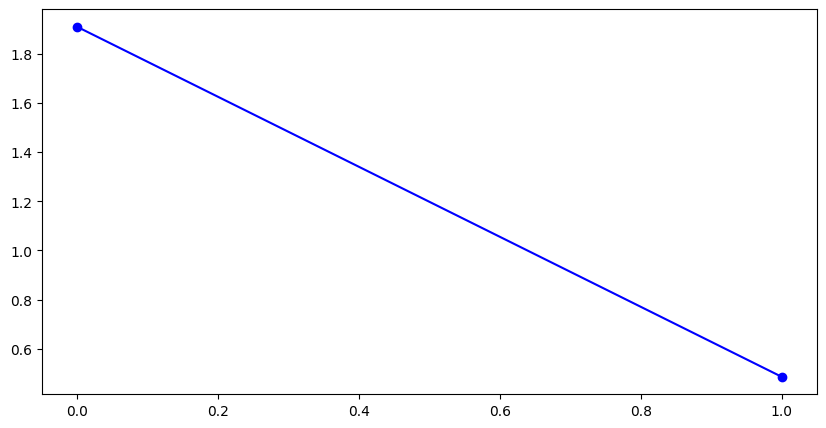

In [7]:
### STEP 7: TRAINING METRICS VISUALIZATION
# Detailed Technical Steps:
# 1. Extract the `log_history` list from the `trainer.state` object, which contains dictionary entries for each logged step.
# 2. Filter the history list to separate 'loss' (training loss) events from 'eval_loss' (validation loss) events.
# 3. Extract the exact step numbers associated with each loss measurement to ensure the X-axis is accurately mapped.
# 4. Plot both curves using Matplotlib. Training loss indicates how well the model is fitting the data, while Validation loss helps detect over/underfitting on unseen data.
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
val_steps = [x['step'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", marker="o")
if val_loss:
    plt.plot(val_steps, val_loss, label="Validation Loss", color="red", linestyle="--", marker="s")

plt.title("Performance Metrics: Training vs Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [8]:
### STEP 8: MODEL ACCURACY EVALUATION
# Detailed Technical Steps:
# 1. Place the model into evaluation mode (`model.eval()`) to disable dropout and stabilize normalization layers.
# 2. Loop through a subset of the unseen evaluation dataset.
# 3. Slice the pre-formatted dataset string precisely at the `<|start_header_id|>assistant<|end_header_id|>` boundary.
# 4. The first half (the prompt) is fed into the model for inference. The second half is retained as the ground truth (`expected_ans`).
# 5. Move the tokenized input to the exact device (MPS/CUDA) where the model resides.
# 6. Use `torch.no_grad()` to temporarily disable gradient tracking, massively reducing memory consumption and speeding up inference.
# 7. Generate a response up to a `max_new_tokens` limit, decode the output IDs back to text, and isolate the assistant's generated string.
# 8. Check for an exact substring match between the prediction and the ground truth to calculate the raw accuracy percentage.
def evaluate_accuracy(dataset_eval):
    model.eval()
    correct = 0
    total = min(10, len(dataset_eval))
    
    for i in range(total):
        row = dataset_eval[i]
        prompt_part = row['text'].split("<|start_header_id|>assistant<|end_header_id|>\n")[0] + "<|start_header_id|>assistant<|end_header_id|>\n"
        expected_ans = row['text'].split("<|start_header_id|>assistant<|end_header_id|>\n")[1].replace("<|eot_id|>", "").strip()
        
        inputs = tokenizer(prompt_part, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=60, pad_token_id=tokenizer.eos_token_id)
            
        prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
        if expected_ans in prediction or prediction in expected_ans:
            correct += 1
            
    return correct / total

acc = evaluate_accuracy(eval_ds)
print(f"Exact/Substring Match Accuracy: {acc * 100:.2f}%")

/Users/kelly/Library/Python/3.10/lib/python/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Exact/Substring Match Accuracy: 10.00%


In [9]:
### STEP 9: MEMORY CLEANUP & LIVE INFERENCE
# Detailed Technical Steps:
# 1. Delete the training `model` and `trainer` objects. Force a Garbage Collection (`gc.collect()`) and clear the GPU/MPS cache to free up VRAM.
# 2. Reload the base Llama-3 model directly from HuggingFace (in 4-bit or FP16 depending on the hardware platform).
# 3. Use `PeftModel.from_pretrained` to load the newly trained LoRA adapter weights (`OUTPUT_DIR`) and merge them efficiently with the base model for inference.
# 4. Define `get_kg_recommendation`, a function that takes raw telemetry data, builds a zero-shot prompt using the Llama-3 template, and generates a network slicing recommendation.
# 5. Execute the function with a sample 5G parameter set (Throughput, Latency, Reliability, etc.) to demonstrate the fine-tuned model's capabilities in real-time.
del model; del trainer; gc.collect(); torch.mps.empty_cache() if torch.backends.mps.is_available() else (torch.cuda.empty_cache() if torch.cuda.is_available() else None)

if use_4bit:
    base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=quant_config, device_map="auto")
else:
    base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")

inference_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)

def get_kg_recommendation(param_string):
    prompt = (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
        f"You are an expert 5G network AI. Analyze the external parameters and error messages, associate them with the correct standard from the Knowledge Graph, and recommend the corresponding network slicing plan.<|eot_id|>\n"
        f"<|start_header_id|>user<|end_header_id|>\n"
        f"External Parameters & Error: {param_string}<|eot_id|>\n"
        f"<|start_header_id|>assistant<|end_header_id|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(inference_model.device)
    with torch.no_grad():
        outputs = inference_model.generate(**inputs, max_new_tokens=80, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()

external_params = "Throughput=715Mbps | Latency=11ms | Reliability=99.967% | Density=2533devices/km2 | Mobility=58km/h | Error=Scale lag | StdTag=TS 23.501"
print(f"INPUT -> External Parameters: {external_params}\n")
print(f"OUTPUT -> AI Inference Results:\n{get_kg_recommendation(external_params)}")

Loading weights:   1%|          | 1/146 [00:00<02:08,  1.13it/s]/Users/kelly/Library/Python/3.10/lib/python/site-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 146/146 [16:48<00:00,  6.91s/it]


INPUT -> External Parameters: Throughput=715Mbps | Latency=11ms | Reliability=99.967% | Density=2533devices/km2 | Mobility=58km/h | Error=Scale lag | StdTag=TS 23.501

OUTPUT -> AI Inference Results:
Associated Standard: TS 23.501
Recommended Plan: TS 23.501 eMBB policy apply, URLLC priority path, mMTC topology sync
